  
## Gotta Graph ’Em All! — Explorando a 1ª geração Pokémon com dados 

---

Farei uso das bibliotecas:
Pandas e Numpy: para manipulação de dados.
Matplotlib e Seaborn: para visualização de dados.
PIL: para manipulação de imagens.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image

In [2]:
data = pd.read_csv('pokemons_kanto.csv', encoding='latin-1')

## Pokémons rápidos tendem a ser mais fortes?
---

Se você nunca jogou pokémon, talvez seja uma novidade para você, mas o pokémon com mais velocidade ataca primeiro em uma batalha. Isso pode ser uma vantagem estratégica, já que o pokémon mais rápido pode causar dano antes que o adversário tenha a chance de atacar. Tendo isso em mente, será que pokémons com mais pontos de velocidade também tendem a ser mais fortes em termos de pontos de ataque?
Para responder essa pergunta, podemos criar um gráfico de dispersão que mostra a relação entre os pontos de velocidade e os pontos de ataque dos pokémons da 1ª geração. Cada ponto no gráfico representa um pokémon, com a velocidade no eixo x e o ataque no eixo y.

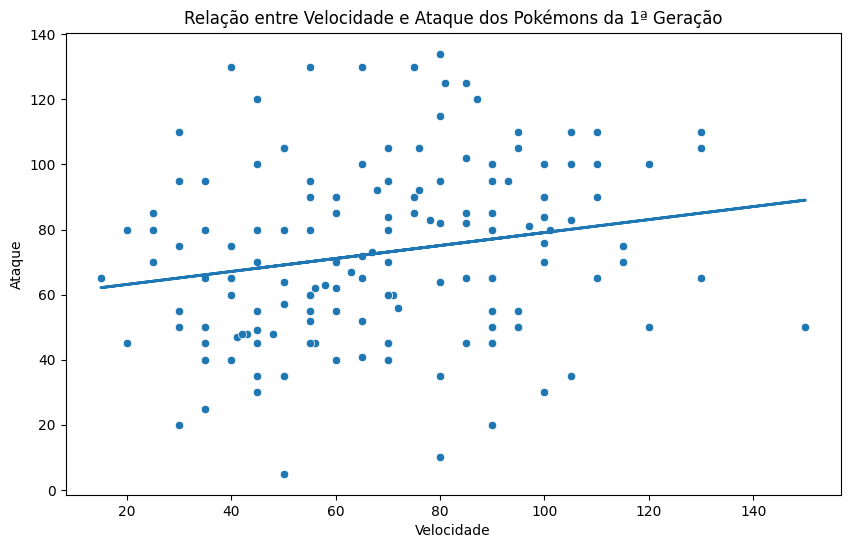

In [3]:
x = data['Velocidade']
y = data['Ataque']

# Ajuste da reta de tendência (regressão linear)
coef = np.polyfit(x, y, 1)
poly1d_fn = np.poly1d(coef)

plt.figure(figsize=(10,6))
sns.scatterplot(data=data, x='Velocidade', y='Ataque')
# Linha de tendência
plt.plot(x, poly1d_fn(x), lw=2)
plt.title('Relação entre Velocidade e Ataque dos Pokémons da 1ª Geração')
plt.xlabel('Velocidade')
plt.ylabel('Ataque')
plt.show()

A partir desse gráfico, podemos observar se há uma correlação positiva entre velocidade e ataque. Se os pontos no gráfico formarem uma tendência ascendente, isso indicaria que pokémons mais rápidos tendem a ter pontos de ataque mais altos. Caso contrário, se os pontos estiverem dispersos sem um padrão claro, isso sugeriria que não há uma relação significativa entre essas duas características.
Como podemos ver, há uma certa tendência de que pokémons mais rápidos também tenham pontos de ataque mais altos, embora existam exceções. Portanto, podemos concluir que, em geral, pokémons rápidos tendem a ser mais fortes em termos de ataque, mas essa não é uma regra absoluta.

# E se o Pikachu do Ash evoluísse?
---

A menos que você tenha vivido em uma caverna, provavelmente já ouviu falar sobre a evolução dos pokémons. A evolução é um processo pelo qual um pokémon se transforma em uma forma mais avançada, geralmente ganhando novos poderes e habilidades. Não há dúvidas que o Pikachu do Ash é formidável, mas será que ele ficaria ainda mais forte se evoluísse para Raichu?
Para responder essa pergunta, podemos comparar os pontos totais (Total Points) de Pikachu e Raichu. Os pontos totais são a soma de todas as características de um pokémon, incluindo HP, ataque, defesa, ataque especial, defesa especial e velocidade. Quanto maior o total de pontos, mais forte é o pokémon.

In [4]:
# Coletando os dados de Pikachu e Raichu
nome = 'pikachu'
pikachu_dados = data.loc[data['Nome'] == nome]

nome = 'raichu'
raichu_dados = data.loc[data['Nome'] == nome]


In [5]:

stat_cols = ['HP', 'Ataque', 'Defesa', 'Ataque Especial', 'Defesa Especial', 'Velocidade']

# Somar os stats base do Pikachu
total_pikachu = pikachu_dados[stat_cols].sum(axis=1).iloc[0]

# Somar os stats base do Raichu
total_raichu = raichu_dados[stat_cols].sum(axis=1).iloc[0]

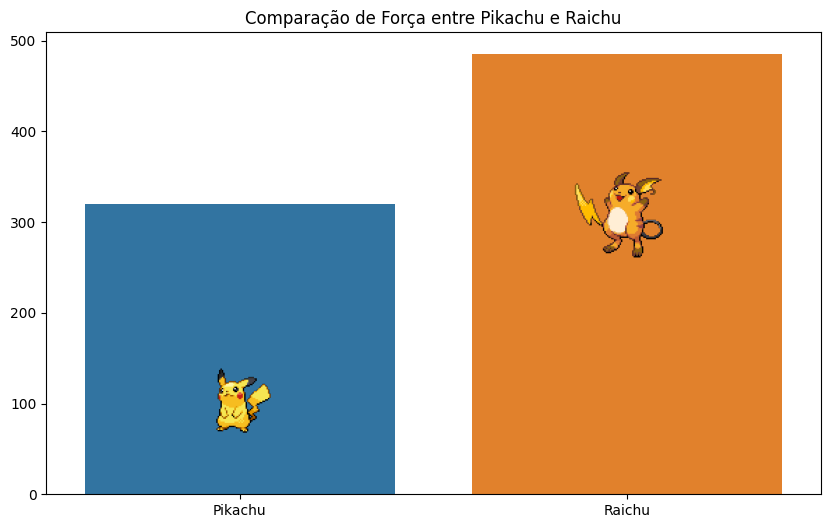

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))
#carregando a imagem do pikachu
img = Image.open("sprites/25.png").convert("RGBA")
imagebox = OffsetImage(img, zoom=1)
ab = AnnotationBbox(imagebox, (0.25, 0.2), xycoords='axes fraction', frameon=False)
ax.add_artist(ab)

#carregando a imagem do raichu
img2 = Image.open("sprites/26.png").convert("RGBA")
imagebox2 = OffsetImage(img2, zoom=1)
ab2 = AnnotationBbox(imagebox2, (0.75, 0.6), xycoords='axes fraction', frameon=False)
ax.add_artist(ab2)

sns.barplot(x=['Pikachu', 'Raichu'], y=[total_pikachu, total_raichu], hue=['Pikachu', 'Raichu'])
plt.title('Comparação de Força entre Pikachu e Raichu')
plt.show()

Uau! Esse choque do trovão foi poderoso! Como podemos ver no gráfico, Raichu, a forma evoluída de Pikachu, tem um Total Points significativamente maior do que Pikachu. Isso sugere que, pelo menos nesse caso específico, a evolução resulta em um pokémon mais forte. Portanto, podemos concluir que Ash faria bem em deixar seu Pikachu evoluir para Raichu, se ele quiser aumentar suas chances de vitória nas batalhas.(O que os torna verdadeiramente fortes é o vínculo que eles compartilham com seus treinadores, afinal de contas.)

# Qual o melhor pokémon inicial?
---

Uma das decisões mais desafiadoras que um treinador de pokémon enfrenta é escolher seu pokémon inicial. Na 1ª geração, os treinadores podiam escolher entre Bulbasaur, Charmander e Squirtle. Cada um desses pokémons tem suas próprias vantagens e desvantagens, mas qual deles é o melhor em termos de força total?
Para responder essa pergunta, vamos analisar um gráfico de linhas que mostra os pontos totais (Total Points) de cada um dos pokémons iniciais ao longo das suas evoluções. Cada linha no gráfico representa um pokémon inicial, e o eixo y mostra os pontos totais e o eixo x mostra as diferentes formas evoluídas (níveis) de cada pokémon.

In [7]:
# Coletando os dados da linha evolutiva de Bulbasaur
bulbasaur_dados = data.loc[data['Nome'] == "bulbasaur"]
ivysaur_dados = data.loc[data['Nome'] == "ivysaur"]
venusaur_dados = data.loc[data['Nome'] == "venusaur"]

# Coletando os dados da linha evolutiva de Charmander
charmander_dados = data.loc[data['Nome'] == "charmander"]
charmeleon_dados = data.loc[data['Nome'] == "charmeleon"]
charizard_dados = data.loc[data['Nome'] == "charizard"]

# Coletando os dados da linha evolutiva de Squirtle
squirtle_dados = data.loc[data['Nome'] == "squirtle"]
wartortle_dados = data.loc[data['Nome'] == "wartortle"]
blastoise_dados = data.loc[data['Nome'] == "blastoise"]

In [8]:
stat_cols = ['HP', 'Ataque', 'Defesa', 'Ataque Especial', 'Defesa Especial', 'Velocidade']

# Somar os stats base do Bulbasaur
total_bulbasaur = bulbasaur_dados[stat_cols].sum(axis=1).iloc[0]

# Somar os stats base do Ivysaur
total_ivysaur = ivysaur_dados[stat_cols].sum(axis=1).iloc[0]

# Somar os stats base do Venusaur
total_venusaur = venusaur_dados[stat_cols].sum(axis=1).iloc[0]

# Somar os stats base do Charmander
total_charmander = charmander_dados[stat_cols].sum(axis=1).iloc[0]

# Somar os stats base do Charmeleon
total_charmeleon = charmeleon_dados[stat_cols].sum(axis=1).iloc[0]

# Somar os stats base do Charizard
total_charizard = charizard_dados[stat_cols].sum(axis=1).iloc[0]

# Somar os stats base do Squirtle
total_squirtle = squirtle_dados[stat_cols].sum(axis=1).iloc[0]

# Somar os stats base do Wartortle
total_wartortle = wartortle_dados[stat_cols].sum(axis=1).iloc[0]

# Somar os stats base do Blastoise  
total_blastoise = blastoise_dados[stat_cols].sum(axis=1).iloc[0]

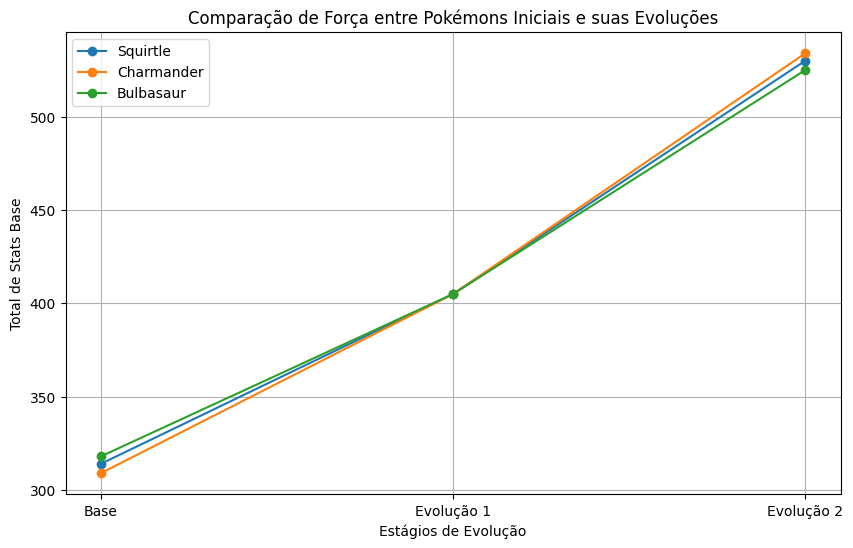

In [ ]:
estagios = ['Base', 'Evolução 1', 'Evolução 2'] 

bulbasaur = [total_bulbasaur, total_ivysaur, total_venusaur]
charmander = [total_charmander, total_charmeleon, total_charizard]
squirtle = [total_squirtle, total_wartortle, total_blastoise]

plt.figure(figsize=(10, 6))
plt.plot(estagios, squirtle, marker='o', label='Squirtle')
plt.plot(estagios, charmander, marker='o', label='Charmander')
plt.plot(estagios, bulbasaur, marker='o', label='Bulbasaur')
plt.xlabel('Estágios de Evolução')
plt.ylabel('Total de Stats Base')
plt.title('Comparação de Força entre Pokémons Iniciais e suas Evoluções')
plt.legend()
plt.grid(True)
plt.show()

Como podemos podemos ver no gráfico, os três iniciais evoluem de formas quase idênticas em termos de Total Points. São iguais em seus primeiros estágios! No entanto, ao atingirem suas formas finais, Charizard (evolução final de Charmander) se destaca ligeiramente com o maior Total Points, seguido por Blastoise (evolução final de Squirtle) e Venusaur (evolução final de Bulbasaur). Portanto, se estivermos apenas considerando a força total, Charmander seria a melhor escolha entre os pokémons iniciais da 1ª geração. No entanto, é importante lembrar que a escolha do pokémon inicial também depende do estilo de jogo e das preferências pessoais de cada treinador.

# Quais os tipos de pokémons mais comuns na 1ª geração?
---

Essa pergunta pode despertar na nossa cabeça a imagem de pokémons normais como Pidgey e 